# FlexiblePCA - Quick Example

Minimal example demonstrating FlexiblePCA with all built-in plotting methods.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA

import flexible_pca
import importlib
importlib.reload(flexible_pca)
from flexible_pca import FlexiblePCA, TrialSpec, create_standard_specs

import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib widget

In [59]:
analyzer = MultiSessionPCA({
    # 'epok': [-100, 300],
    # 'bin_size': 1,
    # 'smooth_ker_size': 25,
    # 'alignment_point': 'go_cue',
    # 'ssd_number': 2,
    # 'normalize': False,
    # 'delta': False,
    # 'subtract_average_PSTH': False,
    'excluded_sessions': [],
    'min_cells_per_session': 10,
    'min_trials_per_condition': 20,
    'monkey': 'fiona',
    'n_pca_components': 5,
    'n_workers': 19,
    'normalize': False,
    'required_directions': [0],
    'required_trial_types': ['GO', 'STOP', 'CONT'],
})

# analyzer.load_data('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')
analyzer.load_data('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data_with_slow_go_data.pkl')

analyzer.cell_df = analyzer.cell_df[analyzer.cell_df['cell_type'] == 'msn']
# analyzer.cell_df = analyzer.cell_df[analyzer.cell_df['trial_session'] == 'fi211025a']

analyzer.validate_all_sessions()
print(f"✓ Valid sessions: {len(analyzer.valid_sessions)}")

cell_df = analyzer.cell_df[analyzer.cell_df['trial_session'].isin(analyzer.valid_sessions)]
cell_df = cell_df[~cell_df['cell_ID'].isin([2134])]
cell_df = cell_df[~cell_df['cell_ID'].isin([1352])]

Loading data from: ../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data_with_slow_go_data.pkl
✓ Database loaded: 1,939,269 cell-trial combinations
  Total sessions: 61
  Total unique cells: 3096
✓ Session statistics computed for 50 sessions
  Excluded sessions: 0
  Candidate sessions: 50
Validating sessions...
--------------------------------------------------------------------------------
✓ fi211102a: Valid (70 cells)
✓ fi211110a: Valid (57 cells)
✓ fi211115a: Valid (56 cells)
✓ fi210909a: Valid (52 cells)
✓ fi210907a: Valid (52 cells)
✓ fi211118a: Valid (46 cells)
✓ fi211104a: Valid (45 cells)
✓ fi211025a: Valid (44 cells)
✓ fi210817a: Valid (43 cells)
✓ fi210811a: Valid (43 cells)
✓ fi211111a: Valid (37 cells)
✓ fi210725a: Valid (36 cells)
✓ fi210818a: Valid (34 cells)
✓ fi210728a: Valid (34 cells)
✓ fi210908a: Valid (34 cells)
✓ fi211109a: Valid (32 cells)
✓ fi211108a: Valid (32 cells)
✓ fi210823a: Valid (31 cells)
✓ fi210721a: Valid (31 cells)
✓ fi210727

In [60]:
# Load data
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl')
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')

# Filter data
# excluded_sessions = ['fi210628', 'fi210629', 'fi210704']
# cell_df = cell_df[~cell_df['trial_session'].isin(excluded_sessions)]
# cell_df = cell_df[cell_df['trial_failed'] == False]

# Filter to sessions with enough cells
min_cells = 15
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= min_cells].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]

print(f"Data loaded: {len(cell_df):,} trials, {cell_df['cell_ID'].nunique()} cells")

Data loaded: 723,793 trials, 1281 cells


# PCA analysis

In [61]:
# Create FlexiblePCA instance
SMOOTH_KER_SIZE = 15
CONTRA_DIR = 0

fpca = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=SMOOTH_KER_SIZE,
    n_components=5,
    pca_function=TruncatedSVD,
    n_jobs=-1,
    z_score=False
)

# Create standard specs: all 6 conditions, align to go_cue, epoch [-50, 500]
ALIGNMENT_POINT = 'first_relevant_saccade'
EPOCH = [-100, 100]
specs = [
    TrialSpec('GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=ALIGNMENT_POINT, success_only=True, failed_only=False, is_slow_go=None),
    # TrialSpec('CONT', direction=CONTRA_DIR, epoch=EPOCH, alignment=ALIGNMENT_POINT, success_only=True, failed_only=False, is_slow_go=None),
    TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=ALIGNMENT_POINT, 
        success_only=True, 
        failed_only=False,
        # label='ERROR_STOP_R'
    ),
]

# Fit PCA on all conditions
fpca.fit(specs)


FITTING PCA

Conditions for fitting:
  GO_R: epoch [-100, 100] ms, aligned to first_relevant_saccade
  STOP_R: epoch [-100, 100] ms, aligned to first_relevant_saccade

Extracting PSTHs for 1281 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1281/1281 [00:03<00:00, 397.48it/s]



✓ PSTH extraction complete
  Total neurons processed: 1281
  Neurons with all conditions: 1281
  Neurons excluded (missing conditions): 0
  Data matrix shape: (1281, 400)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=150.2, min=8, max=435
  STOP_R         : mean=37.5, min=1, max=105

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 4.25 ± 5.06 spikes/sec
  Normalized data: mean=0.000000, std=4.826

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 85.47%
    PC2: 8.18%
    PC3: 2.76%
    PC4: 0.90%
    PC5: 0.69%
  Total variance explained: 98.00%



In [62]:
# Get trajectories and time axes
trajectories = fpca.get_fit_trajectories()
time_axes = {label: fpca.get_time_axis(spec) for spec in specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]}

## PCA explained var


Explained variance by component:
  PC1: 85.47%
  PC2: 8.18%
  PC3: 2.76%
  PC4: 0.90%
  PC5: 0.69%

Total variance explained by 5 components: 98.00%


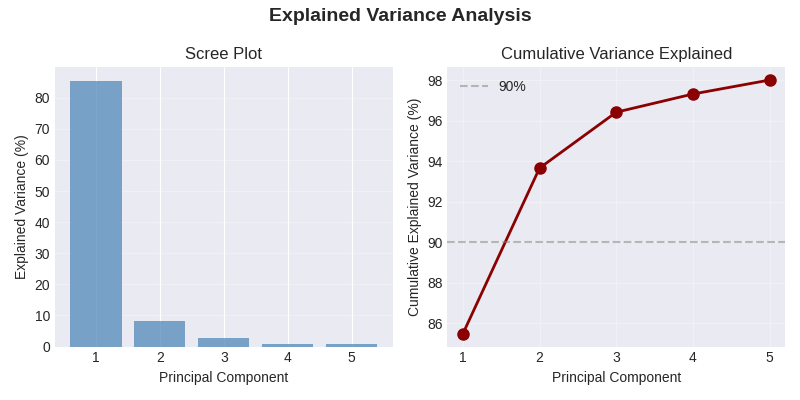

In [63]:
# Plot explained variance
fpca.plot_explained_variance(
    title='Explained Variance Analysis', 
    figsize=(8,4)
)
plt.show()

# Projection SPECs


PROJECTING DATA

Conditions for projection:
  GO_R: epoch [-100, 600] ms, aligned to go_cue
  CONT_R: epoch [-100, 600] ms, aligned to go_cue
  STOP_R: epoch [-100, 600] ms, aligned to go_cue
  ERROR_STOP_R: epoch [-100, 600] ms, aligned to go_cue

Extracting PSTHs for 1281 neurons...


Processing GO_R: 100%|██████████| 1281/1281 [00:03<00:00, 405.42it/s]


(1281,), (1281, 700)
  GO_R: 1281/1281 neurons have data
 :X_condition mean 6.5113640554610175, std 8.21593701124823
 :X_condition shape (1281, 700), means shape (1281, 1)
X_condition_normalized.shape: (1281, 700), PCA components shape: (5, 1281)
  Projection shape: (5, 700)


Processing CONT_R: 100%|██████████| 1281/1281 [00:03<00:00, 410.90it/s]


(1281,), (1281, 700)
  CONT_R: 1281/1281 neurons have data
 :X_condition mean 6.934469441506148, std 8.699695960522988
 :X_condition shape (1281, 700), means shape (1281, 1)
X_condition_normalized.shape: (1281, 700), PCA components shape: (5, 1281)
  Projection shape: (5, 700)


Processing STOP_R: 100%|██████████| 1281/1281 [00:03<00:00, 408.88it/s]


(1281,), (1281, 700)
  STOP_R: 1281/1281 neurons have data
 :X_condition mean 6.661845905228441, std 8.62685632440246
 :X_condition shape (1281, 700), means shape (1281, 1)
X_condition_normalized.shape: (1281, 700), PCA components shape: (5, 1281)
  Projection shape: (5, 700)


Processing ERROR_STOP_R: 100%|██████████| 1281/1281 [00:03<00:00, 410.56it/s]


(1281,), (1281, 700)
  ERROR_STOP_R: 1281/1281 neurons have data
 :X_condition mean 6.723966788472241, std 8.747590840486081
 :X_condition shape (1281, 700), means shape (1281, 1)
X_condition_normalized.shape: (1281, 700), PCA components shape: (5, 1281)
  Projection shape: (5, 700)

✓ Projection complete


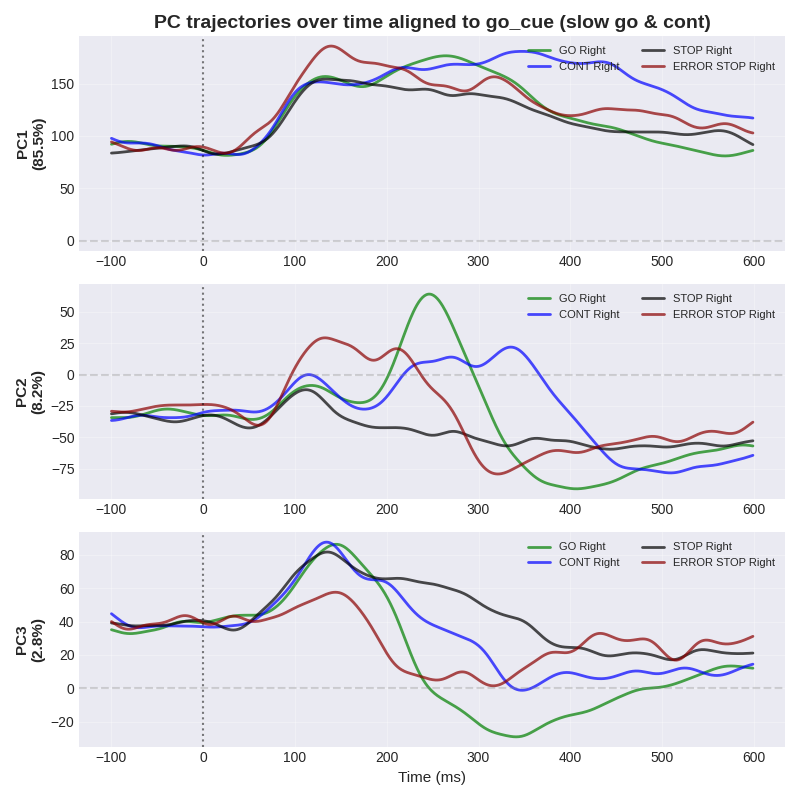

In [64]:
epochs_dict = {
    'go_cue': [-100, 600],
    'stop_cue': [-300, 600],
    'first_relevant_saccade': [-300, 300],
}

proj_alignment_pt= 'go_cue'
is_slow = True
EPOCH = epochs_dict[proj_alignment_pt]
proj_specs = [
    TrialSpec(
        'GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=True, failed_only=False, is_slow_go=is_slow,
    ),
    TrialSpec(
        'CONT', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt,
        success_only=True, failed_only=False, is_slow_go=is_slow,
    ),
]
proj_specs.append(TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=True, failed_only=False, is_slow_go=None,
))
proj_specs.append(TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=False, failed_only=True, is_slow_go=None,
        label='ERROR_STOP_R'
))
projections = fpca.project(proj_specs)
# projections.update(trajectories)
time_axes.update({label: fpca.get_time_axis(spec) for spec in proj_specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]})

fpca.plot_pc_timeseries(
    # trajectories,
    projections,
    time_axes,
    n_pcs=3,
    title=f'PC trajectories over time aligned to {proj_alignment_pt} {"(slow go & cont)" if is_slow else ""}',
    figsize=(8, 8)
)
plt.show()

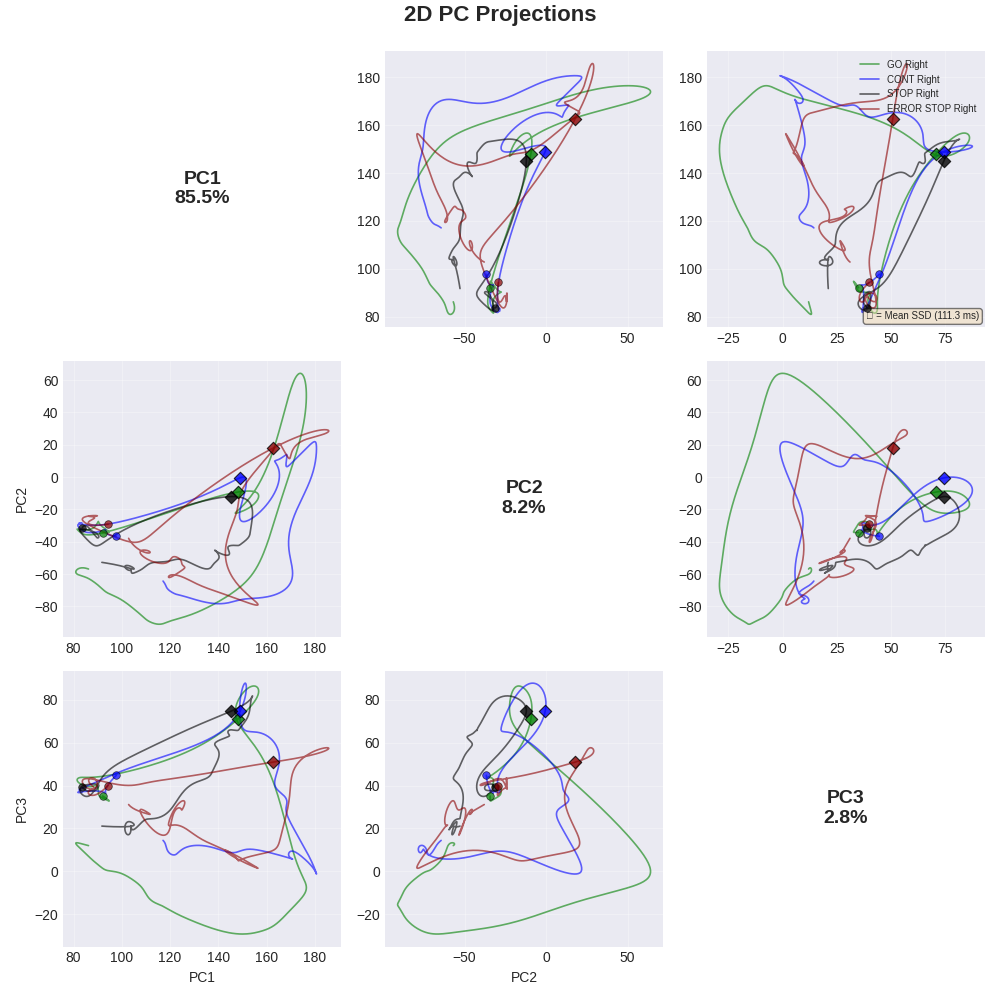

In [65]:
# Plot 2D projections matrix (mean SSD marker added automatically)
fpca.plot_2d_projections(
    # trajectories,
    projections,
    time_axes,
    n_pcs=3,
    title='2D PC Projections',
    figsize=(10, 10)
)
plt.show()

Neurons above mean + std: 156 of 1281 (12.2%)


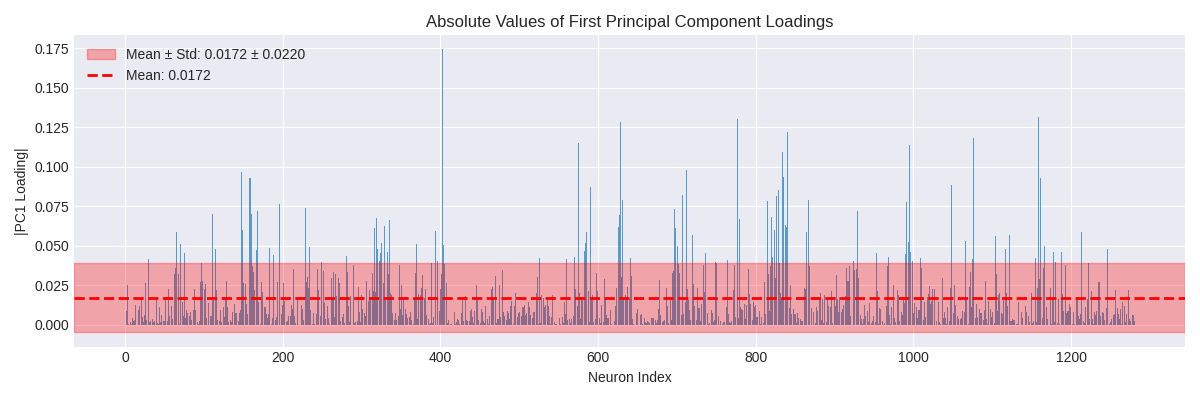

In [66]:
# Plot absolute values of first PC loadings with mean ± std shaded region
pc1_loadings = np.abs(fpca.pca_model.components_[0])

mean_loading = pc1_loadings.mean()
std_loading = pc1_loadings.std()

n_above_threshold = np.sum(pc1_loadings > (mean_loading + std_loading))
print(f"Neurons above mean + std: {n_above_threshold} of {len(pc1_loadings)} ({100*n_above_threshold/len(pc1_loadings):.1f}%)")
plt.figure(figsize=(12, 4))
plt.bar(range(len(pc1_loadings)), pc1_loadings, alpha=0.7)

# Add shaded error region for mean ± std
plt.axhspan(mean_loading - std_loading, mean_loading + std_loading, 
            alpha=0.3, color='red', label=f'Mean ± Std: {mean_loading:.4f} ± {std_loading:.4f}')
plt.axhline(mean_loading, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_loading:.4f}')

plt.xlabel('Neuron Index')
plt.ylabel('|PC1 Loading|')
plt.title('Absolute Values of First Principal Component Loadings')
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
# Map PC1 loadings to cell_IDs used by FlexiblePCA
cell_ids = fpca.cell_ids

pc1_df = pd.DataFrame({
    "cell_ID": np.asarray(cell_ids),
    "pc1_loading": fpca.pca_model.components_[0],
})
pc1_df["abs_pc1_loading"] = pc1_df["pc1_loading"].abs()
pc1_df = pc1_df.sort_values("abs_pc1_loading", ascending=False).reset_index(drop=True)

pc1_df


,cell_ID,pc1_loading,abs_pc1_loading
0,104,0.174202,0.174202
1,190,0.158356,0.158356
2,9234,0.155524,0.155524
3,222,0.131773,0.131773
4,9197,0.130451,0.130451
...,...,...,...
1276,1548,0.000000,0.000000
1277,9727,0.000000,0.000000
1278,1838,0.000000,0.000000
1279,2464,0.000000,0.000000


In [68]:
from concurrent import futures
from tqdm import tqdm
from cell_analysis import Cell

def _compute_cell_psth(cell_id, specs):
    cell = Cell(cell_df[cell_df["cell_ID"] == cell_id])
    cell_psths_dict = {}
    for spec in specs:
        bin_centers, firing_rate, _ = cell.calculate_psth(
            alignment_point=spec.alignment,
            epok=spec.epoch,
            bin_size=1,
            smooth_ker_size=SMOOTH_KER_SIZE,
            success_only=spec.success_only,
            failed_only=spec.failed_only,
            direction=spec.direction,
            trial_type=spec.trial_type
        )
        cell_psths_dict[spec.label] = {
            'cell_id': cell_id,'time': bin_centers, 'fr': firing_rate
        }
    return cell_psths_dict

neuron_stats = []
with futures.ProcessPoolExecutor() as executor:
    future_to_neuron = {executor.submit(_compute_cell_psth, cid, proj_specs): cid for cid in pc1_df['cell_ID']}
    for future in tqdm(futures.as_completed(future_to_neuron), total=len(pc1_df['cell_ID']), desc="Calculating PSTH stats"):
        result = future.result()
        if result is not None:
            neuron_stats.append(result)


# neuron_stats

Calculating PSTH stats: 100%|██████████| 1281/1281 [00:01<00:00, 955.73it/s]


In [69]:
len(neuron_stats)
print(neuron_stats[0].keys())
print(neuron_stats[0]['GO_R'].keys())
rows = []
for entry in neuron_stats:
    row_dict = {t_lbl: entry[t_lbl]["fr"] for t_lbl in entry.keys() if t_lbl != "cell_id"}
    rows.append({
        "cell_ID": entry[list(entry.keys())[0]]["cell_id"],
        **row_dict
    })  
    

psth_df = pd.DataFrame(rows)
psth_df

dict_keys(['GO_R', 'CONT_R', 'STOP_R', 'ERROR_STOP_R'])
dict_keys(['cell_id', 'time', 'fr'])


,cell_ID,GO_R,CONT_R,STOP_R,ERROR_STOP_R
0,9374,"[16.445133807811814, 16.363092222382196, 16.26...","[19.627022999521667, 19.180579895037713, 18.74...","[21.837832674716516, 21.626739512820862, 21.41...","[15.175820708089622, 14.875195882821654, 14.56..."
1,104,"[84.0501289912517, 83.99560742224851, 83.94951...","[92.71900500200194, 92.86506594110384, 92.9909...","[73.08167834015418, 72.56828204262158, 72.0740...","[54.81544887983002, 55.76661033387467, 56.7327..."
2,9240,"[37.24923351301797, 37.11562133032196, 36.9878...","[40.40861698594456, 40.392903442256824, 40.387...","[42.213501233368184, 41.97794076390462, 41.736...","[58.403980713657795, 58.34779605679306, 58.292..."
3,9250,"[34.129187980723025, 34.06454015980122, 34.009...","[28.033979039897066, 28.062583017846833, 28.09...","[26.144187359785576, 26.117131209138552, 26.09...","[30.15169291864488, 30.4034507962551, 30.64439..."
4,9287,"[31.989060306075476, 31.99615384213302, 32.005...","[34.86502692552526, 34.80653890821081, 34.7507...","[44.76585223529386, 44.901575687291064, 45.020...","[39.663929565215724, 39.22273752061246, 38.759..."
...,...,...,...,...,...
1276,2260,"[12.090688403582506, 12.207314210237627, 12.32...","[16.78706155611811, 16.773647915094223, 16.757...","[11.290449238008687, 11.321155120337416, 11.34...","[10.256536390594594, 10.210721300986059, 10.16..."
1277,4010,"[0.14784128849463657, 0.14406799446214108, 0.1...","[0.33344477994562377, 0.318844681802971, 0.304...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3241201189913074, 0.3543984114012964, 0.385..."
1278,1631,"[0.0842498084349723, 0.09256586745488403, 0.10...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1279,9756,"[0.6278334203732839, 0.6356198220107718, 0.643...","[0.16334116440220808, 0.18356978280682681, 0.2...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.075923255752386, 1.0931184927473678, 1.1072..."


In [70]:
# Merge pc1_df with psth_df by cell_ID
merged_df = pc1_df.merge(psth_df, on='cell_ID', how='inner')
merged_df

,cell_ID,pc1_loading,abs_pc1_loading,GO_R,CONT_R,STOP_R,ERROR_STOP_R
0,104,0.174202,0.174202,"[84.0501289912517, 83.99560742224851, 83.94951...","[92.71900500200194, 92.86506594110384, 92.9909...","[73.08167834015418, 72.56828204262158, 72.0740...","[54.81544887983002, 55.76661033387467, 56.7327..."
1,190,0.158356,0.158356,"[34.5239770361899, 34.75708277961242, 34.98762...","[31.352491225022177, 31.50471469225321, 31.665...","[30.66672868338538, 30.967615756228838, 31.283...","[34.085929720025426, 34.15262835079596, 34.218..."
2,9234,0.155524,0.155524,"[52.403299892022545, 52.419881193321785, 52.41...","[52.14754037207831, 51.813940889931935, 51.475...","[43.60125778374046, 43.60097423448806, 43.6069...","[64.86556168942943, 65.56063774212168, 66.2327..."
3,222,0.131773,0.131773,"[14.612641024277051, 14.57696174186231, 14.539...","[13.186502901886053, 13.269089770339034, 13.35...","[13.946658902124309, 14.066891669773089, 14.17...","[15.1906025406992, 15.257434598007128, 15.3220..."
4,9197,0.130451,0.130451,"[28.89050702571627, 28.97697083604211, 29.0602...","[31.438158398945838, 31.47385939198371, 31.514...","[25.70813585238552, 25.82567149307998, 25.9269...","[24.952523150545687, 25.129533018508983, 25.29..."
...,...,...,...,...,...,...,...
1276,1548,0.000000,0.000000,"[0.15857044162103773, 0.1482472269443963, 0.13...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.6850601477503858, 0.7032374351795931, 0.719...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1277,9727,0.000000,0.000000,"[0.004957942431473229, 0.0059357347643181155, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1278,1838,0.000000,0.000000,"[0.00039048534949462507, 0.0004975085157307448...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1279,2464,0.000000,0.000000,"[1.2460309891545274, 1.2736654298295855, 1.302...","[1.7367359487983736, 1.6275670636427244, 1.519...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [71]:
loading_mode = "raw" #"abs" 
weight_column = 'pc1_loading' if loading_mode == "raw" else 'abs_pc1_loading'
psths_dict = {}
for spec in proj_specs:
    time = neuron_stats[0][spec.get_label_for_direction(CONTRA_DIR)]['time']
    firing_rates = np.array(merged_df[spec.label].to_list())
    weighted_avg_fr = np.average(firing_rates, axis=0, weights=merged_df[weight_column])
    weighted_sem = (np.sqrt(np.cov(firing_rates.T, aweights=merged_df['abs_pc1_loading'])) / np.sqrt(len(merged_df))).diagonal()  # Weighted SEM calculation
    psths_dict[spec.label] = {
        'time': time,
        'weighted_avg_fr': weighted_avg_fr,
        'weighted_sem': weighted_sem
    }


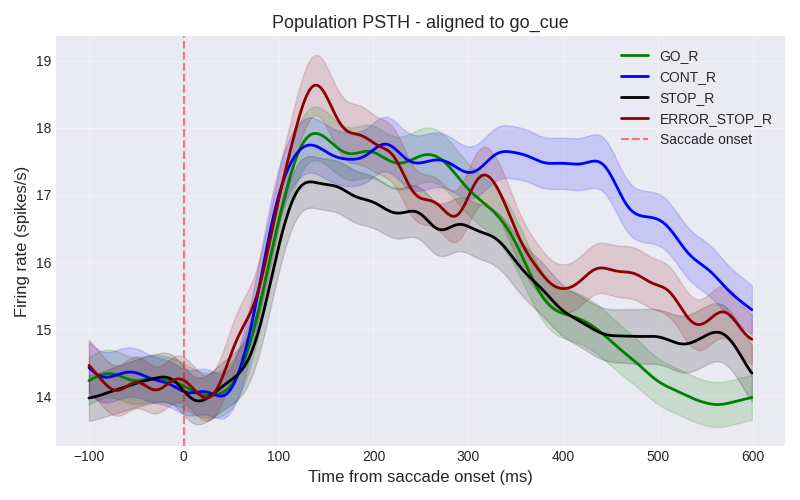

In [72]:
fig_saccade, ax_saccade = plt.subplots(figsize=(8, 5))

for lbl in psths_dict.keys():
    time = psths_dict[lbl]['time']
    y_values = psths_dict[lbl]['weighted_avg_fr']
    y_err = psths_dict[lbl]['weighted_sem']
    color, display_label, linestyle = FlexiblePCA.PLOT_CONFIG[lbl]
    ax_saccade.plot(time, y_values, color=color, linewidth=2, label=lbl)
    ax_saccade.fill_between(time, y_values - y_err, y_values + y_err, 
                            color=color, alpha=0.15)

ax_saccade.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Saccade onset')
ax_saccade.set_xlabel('Time from saccade onset (ms)', fontsize=12)
ax_saccade.set_ylabel('Firing rate (spikes/s)', fontsize=12)
ax_saccade.set_title(f'Population PSTH - aligned to {proj_alignment_pt}', fontsize=13)
ax_saccade.legend()
ax_saccade.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
